# Database Generation

## Start

In [145]:
import numpy as np
np.infty = np.inf
import sys
import cantera as ct
import matplotlib.pyplot as plt
import itertools
import scipy.integrate
import ctypes as xt
import os
import pandas as pd
from ideal_reactor_models import customESC_BM
from ideal_reactor_models import customPFR

In [147]:
def calc_conversion(gas,states, reactant):
    return 100.*(states.Y[0,gas.species_index(reactant)]-states.Y[:,gas.species_index(reactant)])/states.Y[0,gas.species_index(reactant)]
def calc_yield(gas,states, reactant, product):
    return 100.*(states.Y[:,gas.species_index(product)]-states.Y[0,gas.species_index(product)])/states.Y[0,gas.species_index(reactant)]
def calc_selectivity(gas,states, reactant, product):
    return 100.*(states.Y[:,gas.species_index(product)]-states.Y[0,gas.species_index(product)])/(states.Y[0,gas.species_index(reactant)]-states.Y[:,gas.species_index(reactant)])

In [149]:
# define function Cracksim_rates

def CRACKSIM_rates_DLL(gas):
    # CRACKSIM_rates_C call the rates function in CRACKSIM.DLL
    # concentration bassis 

    # initialize temperature and concentrations
    T= gas.T     # [K]
    C_point=gas.concentrations #[mol/l]
    status = 0              

    # copy values to Ctypes to be used as arguements for the Fortran DLL
    C_point= gas.concentrations.ctypes
    T_point = xt.byref(xt.c_double(T)) 
    status = xt.pointer(xt.c_int(status))


    # initalize a ctype pointer to be used as storage for the calculated rates 
    R_point = (xt.c_double*gas.n_species)()     # mol/(s.L)
  
    _ = fortlib.NetRates_C(T_point,C_point,R_point,status)  # function call of CRACKSIM DLL
    
    # convert Ctype to python array
    rates=np.ctypeslib.as_array(R_point)
    rates=rates         #[mol/l/s]
    return rates
    #return rates

In [151]:
# initialize kinetics 
fortlib = xt.CDLL(r"C:\Users\Louis\OneDrive\Bureaublad\ugent\Master2\Thesis\Code_Turboreactor\SA_CRACKSIM.dll") #change this to the location where you stored the dll
status = 0
option = (xt.c_int*20)()
# please note that in python arrays possitions starts counting from 0 
            # option(1) : 
            #      0 use full network
            #      1 use reduced network based on compossition file 
            #      2 use only betanetwork
option[0]= 1
status = xt.pointer(xt.c_int(status)) # setup the pointer to the correct data structure
_ = fortlib.Initialise_CRACKSIM(status,option)            # call the function
status = status[0]
if status==1:
    print("Kinetics and Thermo were read succesfuly")
else:
    print("Errors while reading Kinetics and Thermo")

Kinetics and Thermo were read succesfuly


In [153]:
#Included to suppress the error warnings related to the NASA polynomes
ct.suppress_thermo_warnings()       # currently an issue with Nasapolynomials 
# convert the chem.inp file created by the DLL to yaml file

!ck2yaml --input=chem.inp --transport=transport_chemkin.DAT --permissive > C2KYAML_log.txt

C:\Users\Louis\anacondadownload\envs\cantera-env\lib\site-packages\cantera\ck2yaml.py:2344: UserWarning: NasaPoly2::validate: 
For species CO, discontinuity in h/RT detected at Tmid = 1400
	Value computed using low-temperature polynomial:  -6.48615241904762
	Value computed using high-temperature polynomial: -6.431806107428571

  gas = Solution(out_name)
C:\Users\Louis\anacondadownload\envs\cantera-env\lib\site-packages\cantera\ck2yaml.py:2344: UserWarning: NasaPoly2::validate: 
For species CO2, discontinuity in h/RT detected at Tmid = 1400
	Value computed using low-temperature polynomial:  -29.0113435047619
	Value computed using high-temperature polynomial: -28.977686331657146

  gas = Solution(out_name)
C:\Users\Louis\anacondadownload\envs\cantera-env\lib\site-packages\cantera\ck2yaml.py:2344: UserWarning: NasaPoly2::validate: 
For species NEOC5, discontinuity in cp/R detected at Tmid = 1400
	Value computed using low-temperature polynomial:  42.78292259039995
	Value computed using hig

In [155]:
reac_mech_DLL = 'chem.yaml'
gas_id = 'gas'
gas = ct.Solution(reac_mech_DLL)


In [157]:
print('Gas mechanism contains {} species and {} reactions'.format(gas.n_species, gas.n_reactions))

Gas mechanism contains 239 species and 0 reactions


In [159]:
def ranges(X_in,X_uit,Aantal_Stappen):
    return np.linspace(X_in,X_uit,Aantal_Stappen)

## Class customPFR

In [162]:
HF_z = np.genfromtxt('Heatflux.txt')
z_profile = HF_z[:,0] #m
hf_profile = HF_z[:,1] #W/m2
length = z_profile[-1]-z_profile[0] #m
massflow = 80.4367 #kg/s, copied from file 'TurboReactor & Millisecond_CURE'
diameter = ranges(0.03,1,15) #m
diam = 0.1 #m

#print(np.shape(P_in)[0]) dit geeft de 'lengte' weer. P_in[-1] = P_in[lengte-1]

In [164]:
PFR_calc = customPFR(reac_mech_DLL,gas_id,massflow,diam,CRACKSIM_rates_DLL,energy_type='adiabatic',heat_flux = None, U = None, Tr = None,
                    friction_factors = None)

In [166]:
index_ethylene = PFR_calc.gas.species_index('C2H4')
print(index_ethylene)

56


## Operating Conditions

In [169]:
T_in = ranges(500+273.15, 1500+273.15,15)
Y_in = {'C2H6':1.0, 'H2O':0.3}  # mass fractions
P_in = ranges(1e+5,3.5e+5,15)

## Plots - Variation in Temperature

In [101]:
#excel_file1 = "Database_TEST3.xlsx"
#writer1 = pd.ExcelWriter(excel_file1, engine='xlsxwriter')

Yield_as = []
z_values = None
Temp = []
Conv = []
S = []
for T in T_in:
    PFR_calc.gas.TPY = T,2.0e5,Y_in
    states_PFR_calc = PFR_calc.solve(length,100)
    z = states_PFR_calc.z
    yld = calc_yield(PFR_calc.gas,states_PFR_calc,'C2H6','C2H4')
    conversion = calc_conversion(PFR_calc.gas,states_PFR_calc,'C2H6')
    Yield_as.append(yld)
    Te = states_PFR_calc.T
    Temp.append(Te)
    Conv.append(conversion)
    selectivity = calc_selectivity(PFR_calc.gas,states_PFR_calc,'C2H6','C2H4')
    S.append(selectivity)
    if z_values is None:
        z_values = z

    

    
    #df_species = pd.DataFrame(states_PFR_calc.Y, columns=states_PFR_calc.species_names)
    #df_species['T'] = states_PFR_calc.T
    #df_species['P'] = states_PFR_calc.P
    #st_name = f"T_{int(T)}C"
    #df_species.to_excel(writer1, sheet_name=st_name, index=False)
    
#writer1.close()


C:\Users\Louis\AppData\Local\Temp\ipykernel_28208\172577545.py:6: RuntimeWarning: invalid value encountered in divide
  return 100.*(states.Y[:,gas.species_index(product)]-states.Y[0,gas.species_index(product)])/(states.Y[0,gas.species_index(reactant)]-states.Y[:,gas.species_index(reactant)])


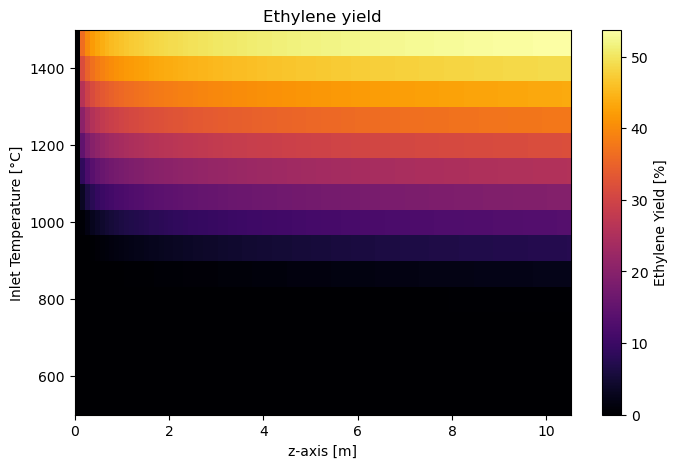

In [103]:
Yield_as = np.array(Yield_as)

plt.figure(figsize=(8,5))
plt.imshow(Yield_as,aspect='auto',origin='lower',extent=[z_values[0],z_values[-1],T_in[0]-273.15,T_in[-1]-273.15],cmap='inferno')
plt.colorbar(label='Ethylene Yield [%]')
plt.xlabel('z-axis [m]')
plt.ylabel('Inlet Temperature [°C]')
plt.title('Ethylene yield')

plt.show()

In [105]:

Temp = np.array(Temp)

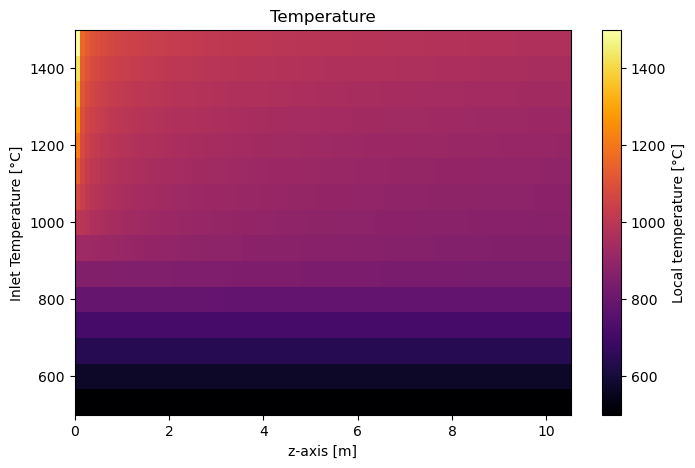

In [107]:
# Deze grafiek toont temperatuursverloop in de reactor in functie van de inlet T. 
#Bij hoge T_in is er een negatieve deltaT, aangezien het adiabaat gemodelleerd is en de reactie endotherm is.
#Bij lage T_in geen deltaT, aangezien er bijna geen reactie optreedt. Zie Yield en Conversion plot.

for i in Temp:
    i -=273.15
plt.figure(figsize=(8,5))
plt.imshow(Temp,aspect='auto',origin='lower',extent=[z_values[0],z_values[-1],T_in[0]-273.15,T_in[-1]-273.15],cmap='inferno')
plt.colorbar(label='Local temperature [°C]')
plt.xlabel('z-axis [m]')
plt.ylabel('Inlet Temperature [°C]')
plt.title('Temperature')

plt.show()

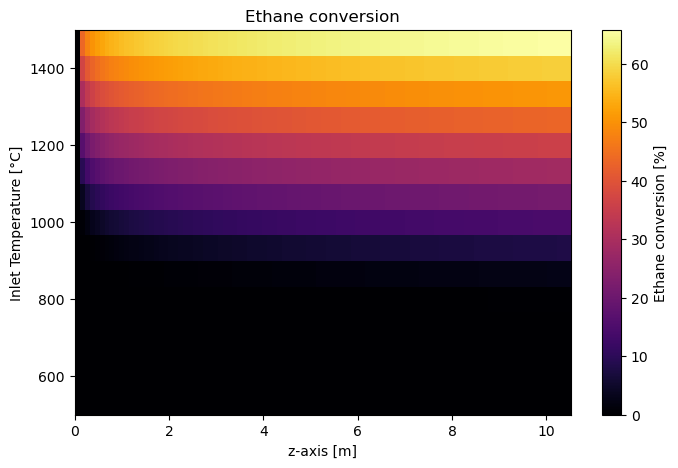

In [109]:
Conv = np.array(Conv)

plt.figure(figsize=(8,5))
plt.imshow(Conv,aspect='auto',origin='lower',extent=[z_values[0],z_values[-1],T_in[0]-273.15,T_in[-1]-273.15],cmap='inferno')
plt.colorbar(label='Ethane conversion [%]')
plt.xlabel('z-axis [m]')
plt.ylabel('Inlet Temperature [°C]')
plt.title('Ethane conversion')

plt.show()

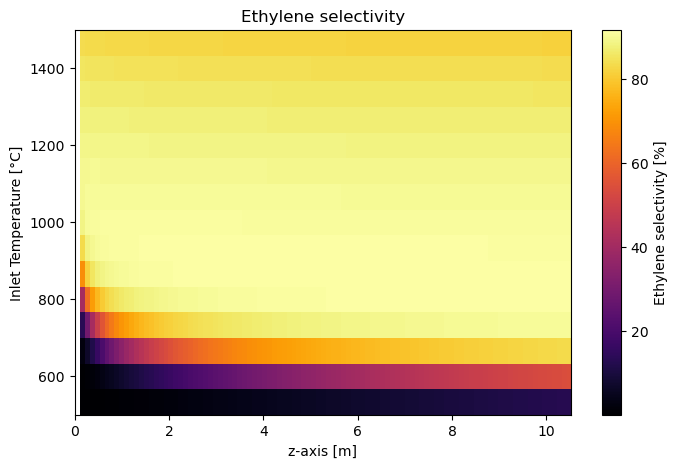

In [112]:
S = np.array(S)

plt.figure(figsize=(8,5))
plt.imshow(S,aspect='auto',origin='lower',extent=[z_values[0],z_values[-1],T_in[0]-273.15,T_in[-1]-273.15],cmap='inferno')
plt.colorbar(label='Ethylene selectivity [%]')
plt.xlabel('z-axis [m]')
plt.ylabel('Inlet Temperature [°C]')
plt.title('Ethylene selectivity')

plt.show()

## Plots - Variation in pressure

In [115]:
Yield_asP = []
z_valuesP = None
TempP = []
ConvP = []
SP = []
Pressure = []
for P in P_in:
    PFR_calc.gas.TPY = 1273.15,P,Y_in
    states_PFR_calc = PFR_calc.solve(length,100)
    z = states_PFR_calc.z
    yld = calc_yield(PFR_calc.gas,states_PFR_calc,'C2H6','C2H4')
    conversion = calc_conversion(PFR_calc.gas,states_PFR_calc,'C2H6')
    Yield_asP.append(yld)
    Te = states_PFR_calc.T
    Pr = states_PFR_calc.P
    TempP.append(Te)
    ConvP.append(conversion)
    Pressure.append(Pr)
    selectivity = calc_selectivity(PFR_calc.gas,states_PFR_calc,'C2H6','C2H4')
    SP.append(selectivity)
    if z_valuesP is None:
        z_valuesP = z

C:\Users\Louis\AppData\Local\Temp\ipykernel_28208\172577545.py:6: RuntimeWarning: invalid value encountered in divide
  return 100.*(states.Y[:,gas.species_index(product)]-states.Y[0,gas.species_index(product)])/(states.Y[0,gas.species_index(reactant)]-states.Y[:,gas.species_index(reactant)])


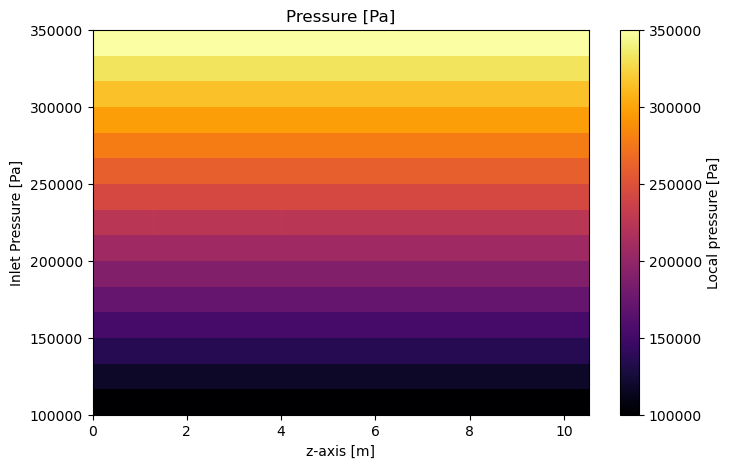

In [118]:
plt.figure(figsize=(8,5))
plt.imshow(Pressure,aspect='auto',origin='lower',extent=[z_valuesP[0],z_valuesP[-1],P_in[0],P_in[-1]],cmap='inferno')
plt.colorbar(label='Local pressure [Pa]')
plt.xlabel('z-axis [m]')
plt.ylabel('Inlet Pressure [Pa]')
plt.title('Pressure [Pa]')

plt.show()

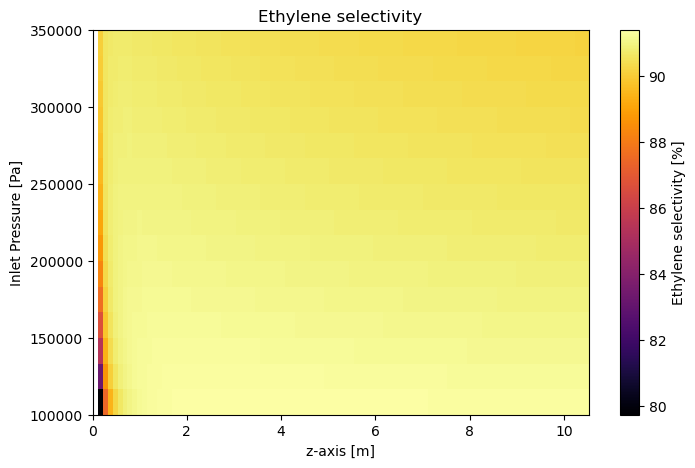

In [120]:
SP = np.array(SP)

plt.figure(figsize=(8,5))
plt.imshow(SP,aspect='auto',origin='lower',extent=[z_valuesP[0],z_valuesP[-1],P_in[0],P_in[-1]],cmap='inferno')
plt.colorbar(label='Ethylene selectivity [%]')
plt.xlabel('z-axis [m]')
plt.ylabel('Inlet Pressure [Pa]')
plt.title('Ethylene selectivity')

plt.show()

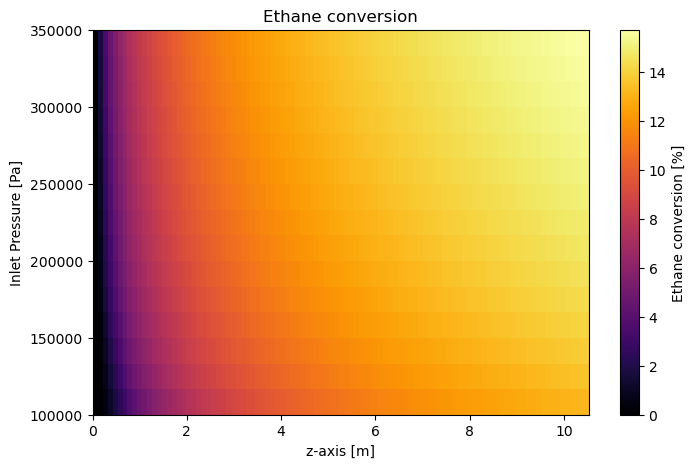

In [122]:
ConvP = np.array(ConvP)

plt.figure(figsize=(8,5))
plt.imshow(ConvP,aspect='auto',origin='lower',extent=[z_valuesP[0],z_valuesP[-1],P_in[0], P_in[-1]],cmap='inferno')
plt.colorbar(label='Ethane conversion [%]')
plt.xlabel('z-axis [m]')
plt.ylabel('Inlet Pressure [Pa]')
plt.title('Ethane conversion')

plt.show()

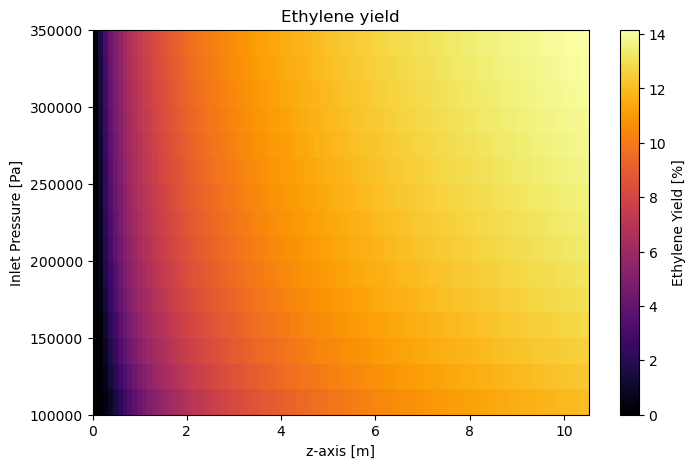

In [124]:
Yield_asP = np.array(Yield_asP)

plt.figure(figsize=(8,5))
plt.imshow(Yield_asP,aspect='auto',origin='lower',extent=[z_valuesP[0],z_valuesP[-1],P_in[0],P_in[-1]],cmap='inferno')
plt.colorbar(label='Ethylene Yield [%]')
plt.xlabel('z-axis [m]')
plt.ylabel('Inlet Pressure [Pa]')
plt.title('Ethylene yield')

plt.show()

## Plots - Variation in H2O mass fraction

In [172]:
ConvH2O = []
selecH2O = []
yieldH2O = []

z_axis = None
mf_range = ranges(0,15,15)

for X in mf_range:
    PFR_calc.gas.TPY = 1273.15, 2e+05, {'C2H6':1.0, 'H2O':X}
    states_PFR_calc_H2O = PFR_calc.solve(length,100)
    if z_axis is None:
        z_axis = states_PFR_calc_H2O.z
        
    yld = calc_yield(PFR_calc.gas,states_PFR_calc_H2O,'C2H6','C2H4')
    yieldH2O.append(yld)
    
    selectiviteit = calc_selectivity(PFR_calc.gas,states_PFR_calc_H2O,'C2H6','C2H4')
    selecH2O.append(selectiviteit)

    conversie = calc_conversion(PFR_calc.gas,states_PFR_calc_H2O,'C2H6')
    ConvH2O.append(conversie)

C:\Users\Louis\AppData\Local\Temp\ipykernel_28208\172577545.py:6: RuntimeWarning: invalid value encountered in divide
  return 100.*(states.Y[:,gas.species_index(product)]-states.Y[0,gas.species_index(product)])/(states.Y[0,gas.species_index(reactant)]-states.Y[:,gas.species_index(reactant)])


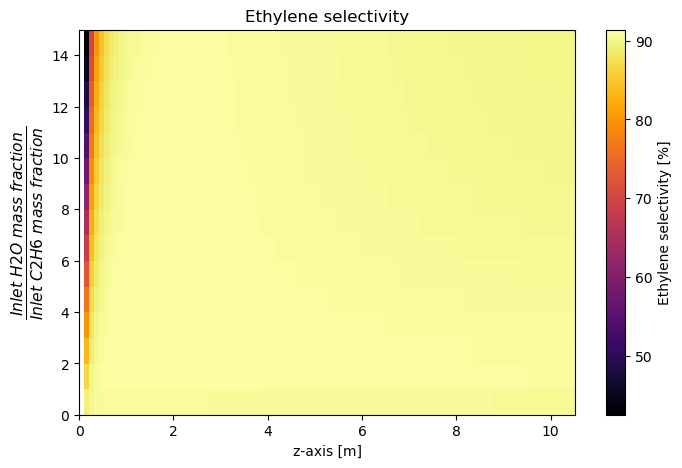

In [190]:
selecH2O = np.array(selecH2O)
plt.figure(figsize=(8,5))
plt.imshow(selecH2O,aspect='auto',origin='lower',extent=[z_axis[0],z_axis[-1],mf_range[0],mf_range[-1]],cmap='inferno')
plt.colorbar(label='Ethylene selectivity [%]')
plt.xlabel('z-axis [m]')
plt.ylabel(r'$\frac{Inlet\ H2O\ mass\ fraction}{Inlet\ C2H6\ mass\ fraction}$', fontsize = 16)
plt.title('Ethylene selectivity')

plt.show()

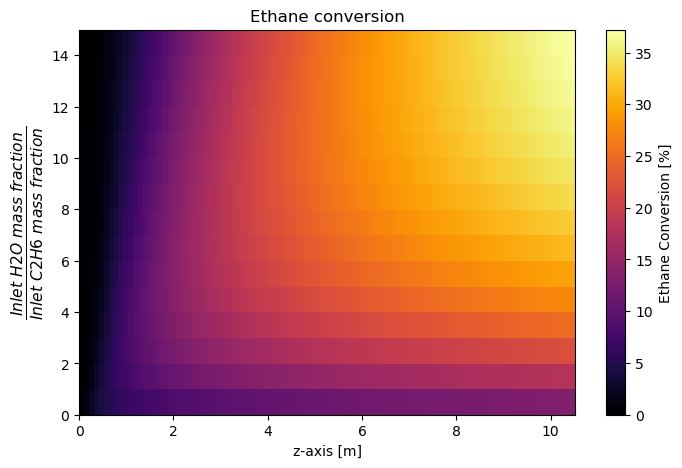

In [186]:
ConvH2O = np.array(ConvH2O)
plt.figure(figsize=(8,5))
plt.imshow(ConvH2O,aspect='auto',origin='lower',extent=[z_axis[0],z_axis[-1],mf_range[0],mf_range[-1]],cmap='inferno')
plt.colorbar(label='Ethane Conversion [%]')
plt.xlabel('z-axis [m]')
plt.ylabel(r'$\frac{Inlet\ H2O\ mass\ fraction}{Inlet\ C2H6\ mass\ fraction}$', fontsize = 16)
plt.title('Ethane conversion')

plt.show()

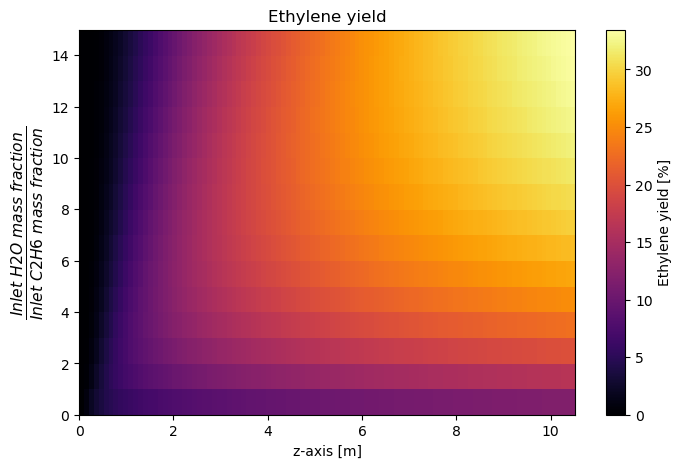

In [188]:
yieldH2O = np.array(yieldH2O)
plt.figure(figsize=(8,5))
plt.imshow(yieldH2O,aspect='auto',origin='lower',extent=[z_axis[0],z_axis[-1],mf_range[0],mf_range[-1]],cmap='inferno')
plt.colorbar(label='Ethylene yield [%]')
plt.xlabel('z-axis [m]')
plt.ylabel(r'$\frac{Inlet\ H2O\ mass\ fraction}{Inlet\ C2H6\ mass\ fraction}$', fontsize = 16)
plt.title('Ethylene yield')

plt.show()

## Excel file: variation in Temperature, Pressure, Diameter, H2O fraction, ...

In [219]:
# Ter Info
#T_in = ranges(500+273.15,1500+273.15,20) #K
#P_in = ranges(1e+5,2.5e+5,15) #Pa
#Y_in = {'C2H6':1.0, 'H2O':0.3} # mass fractions
#H2_frac = ranges(0,1,15)
#Y_in variabel maken:
#Y_in1 = {'C2H6':(1-i), 'H2O':i} for i in H2_frac

#HF_z = np.genfromtxt('Heatflux.txt')
#z_profile = HF_z[:,0] #m
#hf_profile = HF_z[:,1] #W/m2
#length = z_profile[-1]-z_profile[0] #m
#massflow = 80.4367 #kg/s, copied from file 'TurboReactor & Millisecond_CURE'
#diameter = ranges(0.03,1,15) #m
#diam = 0.1 #m

In [ ]:
#excel_file2 = "Database_TEST4.xlsx"
#writer2 = pd.ExcelWriter(excel_file2, engine='xlsxwriter')
for T in T_in:
    for P in P_in:
        for D in diameter:
            PFR_calc1 = customPFR(reac_mech_DLL,gas_id,massflow,D,CRACKSIM_rates_DLL,energy_type='adiabatic',heat_flux = None, U = None, Tr = None,
                    friction_factors = None)
            PFR_calc1.gas.TPY = T,P,Y_in
            states_PFR_calc1 = PFR_calc1.solve(length,100)
            #df_species = pd.DataFrame(states_PFR_calc.Y, columns=states_PFR_calc.species_names)
            #df_species['T'] = states_PFR_calc.T
            #df_species['P'] = states_PFR_calc.P
            #st_name = f"T_{int(T)}C"
            #df_species.to_excel(writer2, sheet_name=st_name, index=False)
#writer2.close()     

In [141]:
status = xt.pointer(xt.c_int(status)) # setup the pointer to the correct data structure
_ = fortlib.terminate_CRACKSIM(status)            # call the function
status = status[0]
if status==1:
  print("Memory released succesfully")
else:
  print("Errors while deallocating arrays")

del fortlib

Memory released succesfully
